In [1]:
from sklearn.decomposition import PCA
import scipy
import numpy as np
import os
from pathlib import Path
import math
import matplotlib.pyplot as plt
import pickle as pkl
from datetime import datetime
current_datetime = datetime.now()
formatted_datetime = current_datetime.strftime("%Y%m%d_%H%M%S")

required_keys = ['spikepow', 'threshcross', 'cue', 'speech_onsets', 'speech_offsets', 'spikepow_with_post_end', 'threshcross_with_post_end']
participant = 't16'
session = 'word-loudness'
savepath_fig = f'../analyses_figures/{participant}/{session}/pca/'
savepath_data = f'../analyses_figures_data/{participant}/{session}/pca/'
if not os.path.exists(savepath_fig):
    os.makedirs(savepath_fig, exist_ok=True)
if not os.path.exists(savepath_data):
    os.makedirs(savepath_data, exist_ok=True)

nbins_before_onset = 75 # 100ms
nbins_after_onset = 75 # 400ms
n_channels = 128
amplitudes = ['MIME', 'WHISPER', 'NORMAL', 'LOUD']
# words = ['be', 'my', 'know', 'do', 'have', 'going'] # use when all the data is provided via Dryad
words = ['be', 'my', ] # use with sample data provided in Github

amplitude_color = [
    (167/255, 185/255, 207/255),
    (114/255, 159/255, 207/255),
    (53/255, 126/255, 221/255),
    (0, 79/255, 158/255),
]
word_color = [
    (0.9254902, 0.12156863, 0.14117647),
    (0.98431373, 0.72941176, 0.07058824),
    # [0.57254902, 0.78431373, 0.24313725],  # Commented out in MATLAB
    (0.384, 0.682, 0.2),
    (0.43137255, 0.79607843, 0.85490196),
    # (0.26529412, 0.40686275, 0.72490196),
    [0.45568627, 0.31764706, 0.63529412],  # Commented out in MATLAB
    (0.84705882, 0.2627451, 0.59215686)
]

In [2]:
# load data
data_path = f'../sample_neural_data/{participant}/{session}/' # t15.2023.11.04 has using_correct_electrode_mapping = 0
files = os.listdir(data_path)

data = {}

for file in files:
    name, extension = os.path.splitext(file)
    if extension == '.mat':
        fullPath = str(Path(data_path, file).resolve())
        print(f'Loading {fullPath} ...')
        data_temp_required = scipy.io.loadmat(fullPath)

        # append data to master dict
        if data == {}:
            for key in required_keys:
                data[key] = data_temp_required[key]
        else:
            for key in required_keys:
                data[key] = np.append(data[key], data_temp_required[key], axis = -1)

print('Data loaded ...')
for key in data:
    print(key, data[key].shape)

Loading /Users/aparnasrinivasan/Downloads/NPL/speech_amplitude/paper_submission/srinivasan-speech-modes/sample_neural_data/t16/word-loudness/t16_sample_data.mat ...
Data loaded ...
spikepow (1, 9)
threshcross (1, 9)
cue (9,)
speech_onsets (1, 9)
speech_offsets (1, 9)
spikepow_with_post_end (1, 9)
threshcross_with_post_end (1, 9)


In [3]:
# load spikepow around speech onset, get average spike for word-amp combination
n_trials = len(data['cue'])
word_amp_trial_avg = []
word_label = []
amp_label = []
for word in words:
    for amp in amplitudes:
        print(word, amp)
        inds = [k for k in range(n_trials) if amp in data['cue'][k] and 
                word in data['cue'][k]]
        
        x_spikepow = np.empty((0, nbins_before_onset + nbins_after_onset, n_channels))
        x_threshcross = np.empty((0, nbins_before_onset + nbins_after_onset, n_channels))
        for k in inds:
                spikepow = np.squeeze(data['spikepow_with_post_end'])[k][:, :n_channels]
                threshcross = np.squeeze(data['threshcross_with_post_end'])[k][:, :n_channels]
                start_ind = np.squeeze(data['speech_onsets'])[k]
                end_ind = np.squeeze(data['speech_offsets'])[k]
                # binned start and end ind
                start_ind = math.floor((start_ind/30000) * (1000/10)) # divide by sampling rate (30kHZ), scale it to ms by multiplying with 1000, divide by 10 to get bin index
                end_ind = math.ceil((end_ind/30000) * (1000/10)) # divide by sampling rate (30kHZ), scale it to ms by multiplying with 1000, divide by 10 to get bin index

                if np.expand_dims(spikepow[start_ind - nbins_before_onset: start_ind + nbins_after_onset, :], 0).shape[1] == nbins_before_onset + nbins_after_onset:
                        # add spikepow and threshcross around speech onset
                        temp_spikepow = spikepow[start_ind - nbins_before_onset: start_ind + nbins_after_onset, :] # shape (time_bins x 256)
                        x_spikepow = np.append(x_spikepow, np.expand_dims(temp_spikepow, 0), axis = 0)

                        temp_threshcross = threshcross[start_ind - nbins_before_onset: start_ind + nbins_after_onset, :] # shape (time_bins x 256)
                        x_threshcross = np.append(x_threshcross, np.expand_dims(temp_threshcross, 0), axis = 0)

        print(x_spikepow.shape)
        if x_spikepow.shape[0] != 0:
                x_spikepow_mean = np.mean(x_spikepow, axis = 0) # avg across trials
                word_amp_trial_avg.append(x_spikepow_mean)
                word_label.append(words.index(word))
                amp_label.append(amplitudes.index(amp))

amp_word_trial_avg = np.array(word_amp_trial_avg)
print(amp_word_trial_avg.shape)

be MIME
(1, 150, 128)
be WHISPER
(1, 150, 128)
be NORMAL
(1, 150, 128)
be LOUD
(1, 150, 128)
my MIME
(1, 150, 128)
my WHISPER
(1, 150, 128)
my NORMAL
(1, 150, 128)
my LOUD
(1, 150, 128)
(8, 150, 128)


n_samples = n_trial x t, n_feat  = n_channels; plot after averaging across time

# PCA on spikepow

In [4]:
# compute pca all components, but take only 3 for plotting
pca = PCA(n_components=3)

# no averaging across time; n_samples == n_conditions x time (25 x 50), n_features == n_channels (256)
X = amp_word_trial_avg.reshape(-1, n_channels)
print('PCA input shape:', X.shape)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

x_pca = pca.fit_transform(X_scaled) # n_trials x (n_channels x time_bins)
print('PCA transformed shape:', x_pca.shape)

x_pca_flatten_time_pca_on_ch = x_pca

# reshape it back to n_trials x time x n_pca_components
x_pca = x_pca.reshape(amp_word_trial_avg.shape[0], -1, 3)
print('PCA reshaped back to n_trials x time x n_pca_feat:', x_pca.shape)
# averge across time
x_pca = np.mean(x_pca, axis=1)
print('Average across time:', x_pca.shape)

x_ax = x_pca[:, 0]
y_ax = x_pca[:, 1]
z_ax = x_pca[:, 2]

print('PCA x_ax:', x_ax)
print('PCA y_ax:', y_ax)
print('PCA z_ax:', z_ax)


PCA input shape: (1200, 128)
PCA transformed shape: (1200, 3)
PCA reshaped back to n_trials x time x n_pca_feat: (8, 150, 3)
Average across time: (8, 3)
PCA x_ax: [-3.94172643  2.56809745  0.72614024  0.85637123 -2.51595267  0.57367904
  0.08063784  1.65275329]
PCA y_ax: [-0.07338468 -2.59268335 -0.98014747  0.2506691  -0.80663267 -1.0906149
  0.90546814  4.38732582]
PCA z_ax: [ 3.64380245 -1.05519084 -0.48512391 -1.04698927 -0.5738535  -0.48711966
 -0.70222583  0.70670056]


In [5]:
# explained variance
temp = pca.fit(X_scaled)
print('explained variance - spb')
temp.explained_variance_ratio_

explained variance - spb


array([0.30125622, 0.08169723, 0.06029189])

In [6]:
pca.components_.shape
with open(f'{savepath_data}{participant}_{session}_{nbins_before_onset}_{nbins_after_onset}_pca_weights.pkl', 'wb') as f:
    pkl.dump({'pca_weights': pca.components_}, f)

## Plot spb PCA projections 

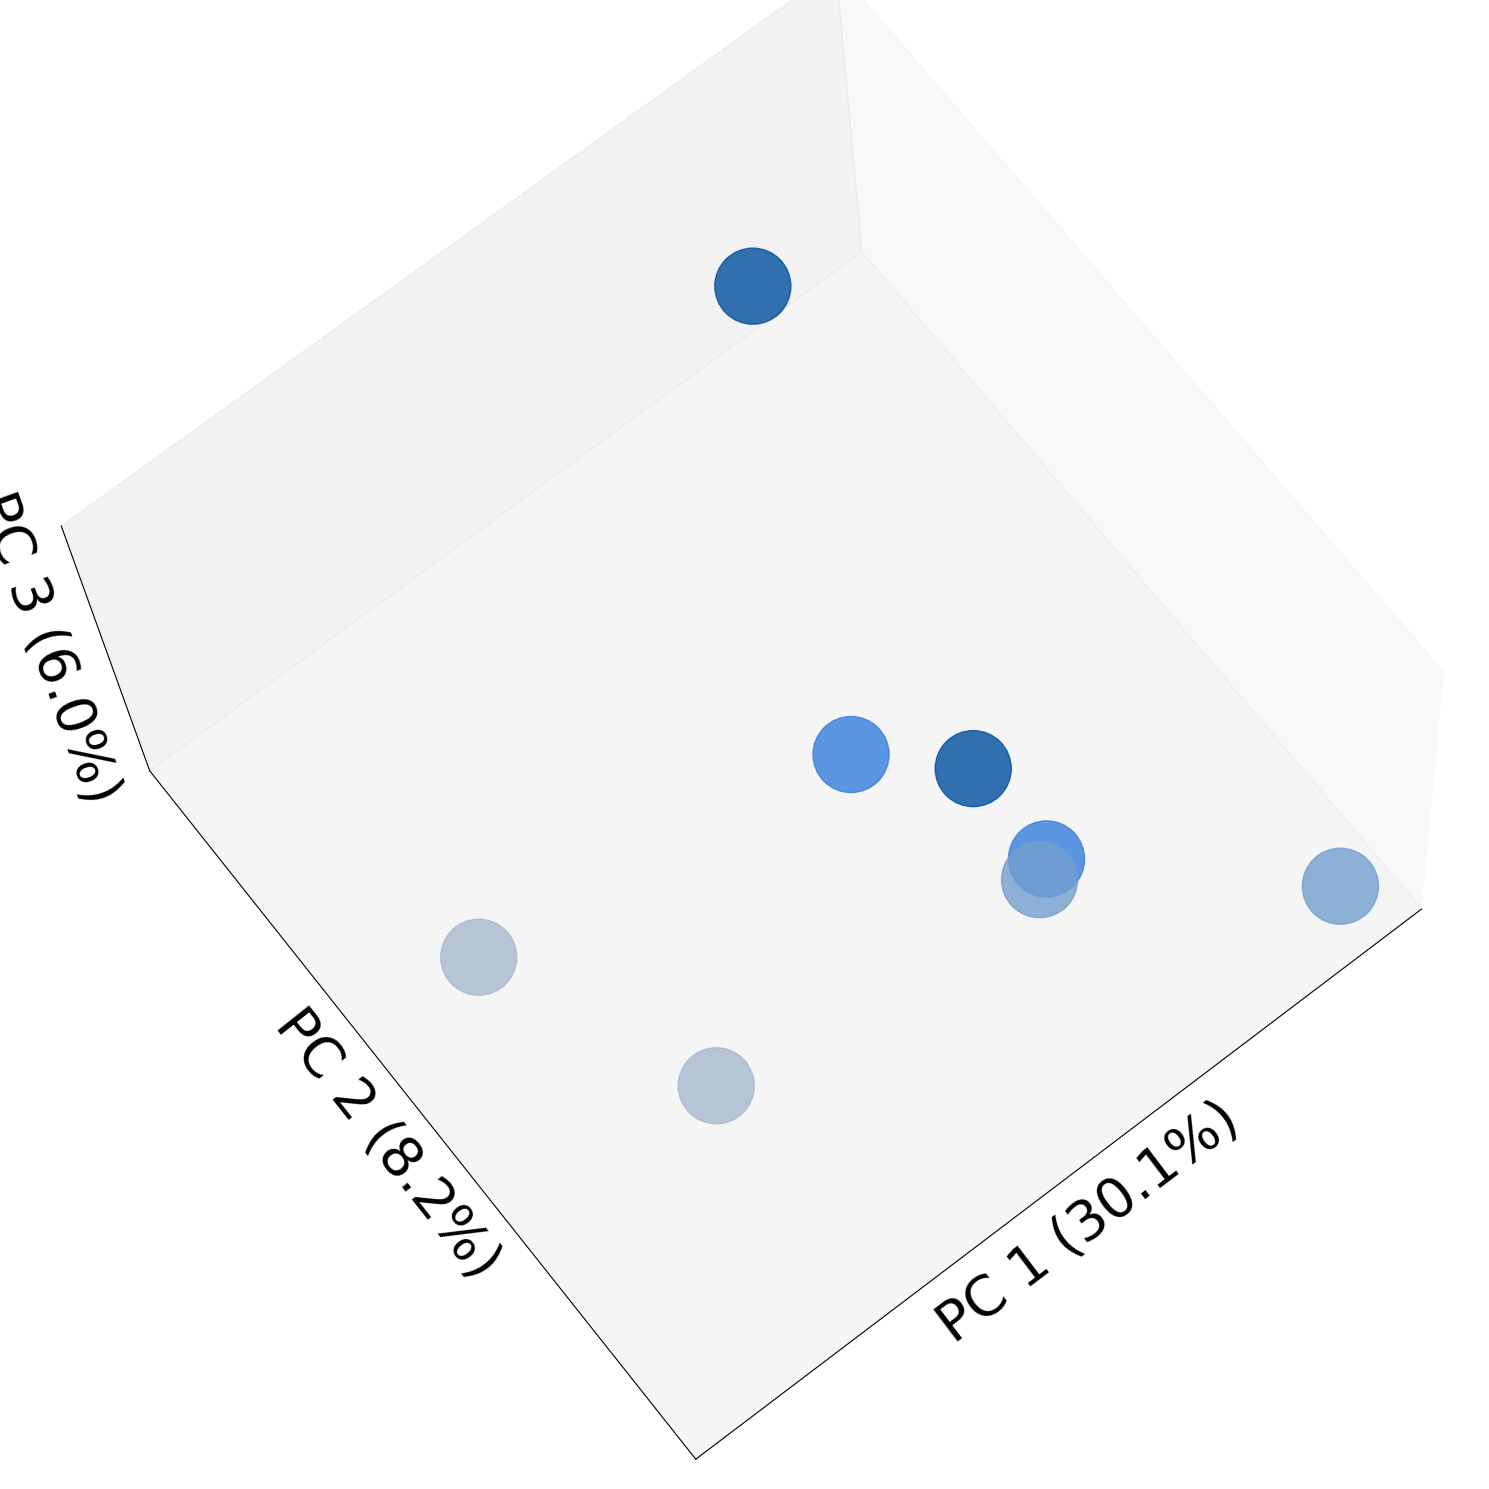

In [7]:
fontsize = 40
scatter_size = 3000
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_ax, y_ax, z_ax, color=np.array(amplitude_color)[amp_label], s=scatter_size, alpha = 0.8)

expl_var = temp.explained_variance_ratio_
ax.set_xlabel(f'PC 1 ({expl_var[0]*100:.1f}%)', fontsize = fontsize)
ax.set_ylabel(f'PC 2 ({expl_var[1]*100:.1f}%)', fontsize = fontsize)
ax.set_zlabel(f'PC 3 ({expl_var[2]*100:.1f}%)', fontsize = fontsize)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.view_init(elev = 70, azim = -120, roll = 8) # rev1 (comparison between spb and thx, comparison between -100, 400 ms and -750, 750 ms)
ax.grid(False)
fig.tight_layout()
# save figure
plt.savefig(f'{savepath_fig}{participant}_{session}_{formatted_datetime}_pca_amplitude_spb_{nbins_before_onset}_{nbins_after_onset}.png', format='png')


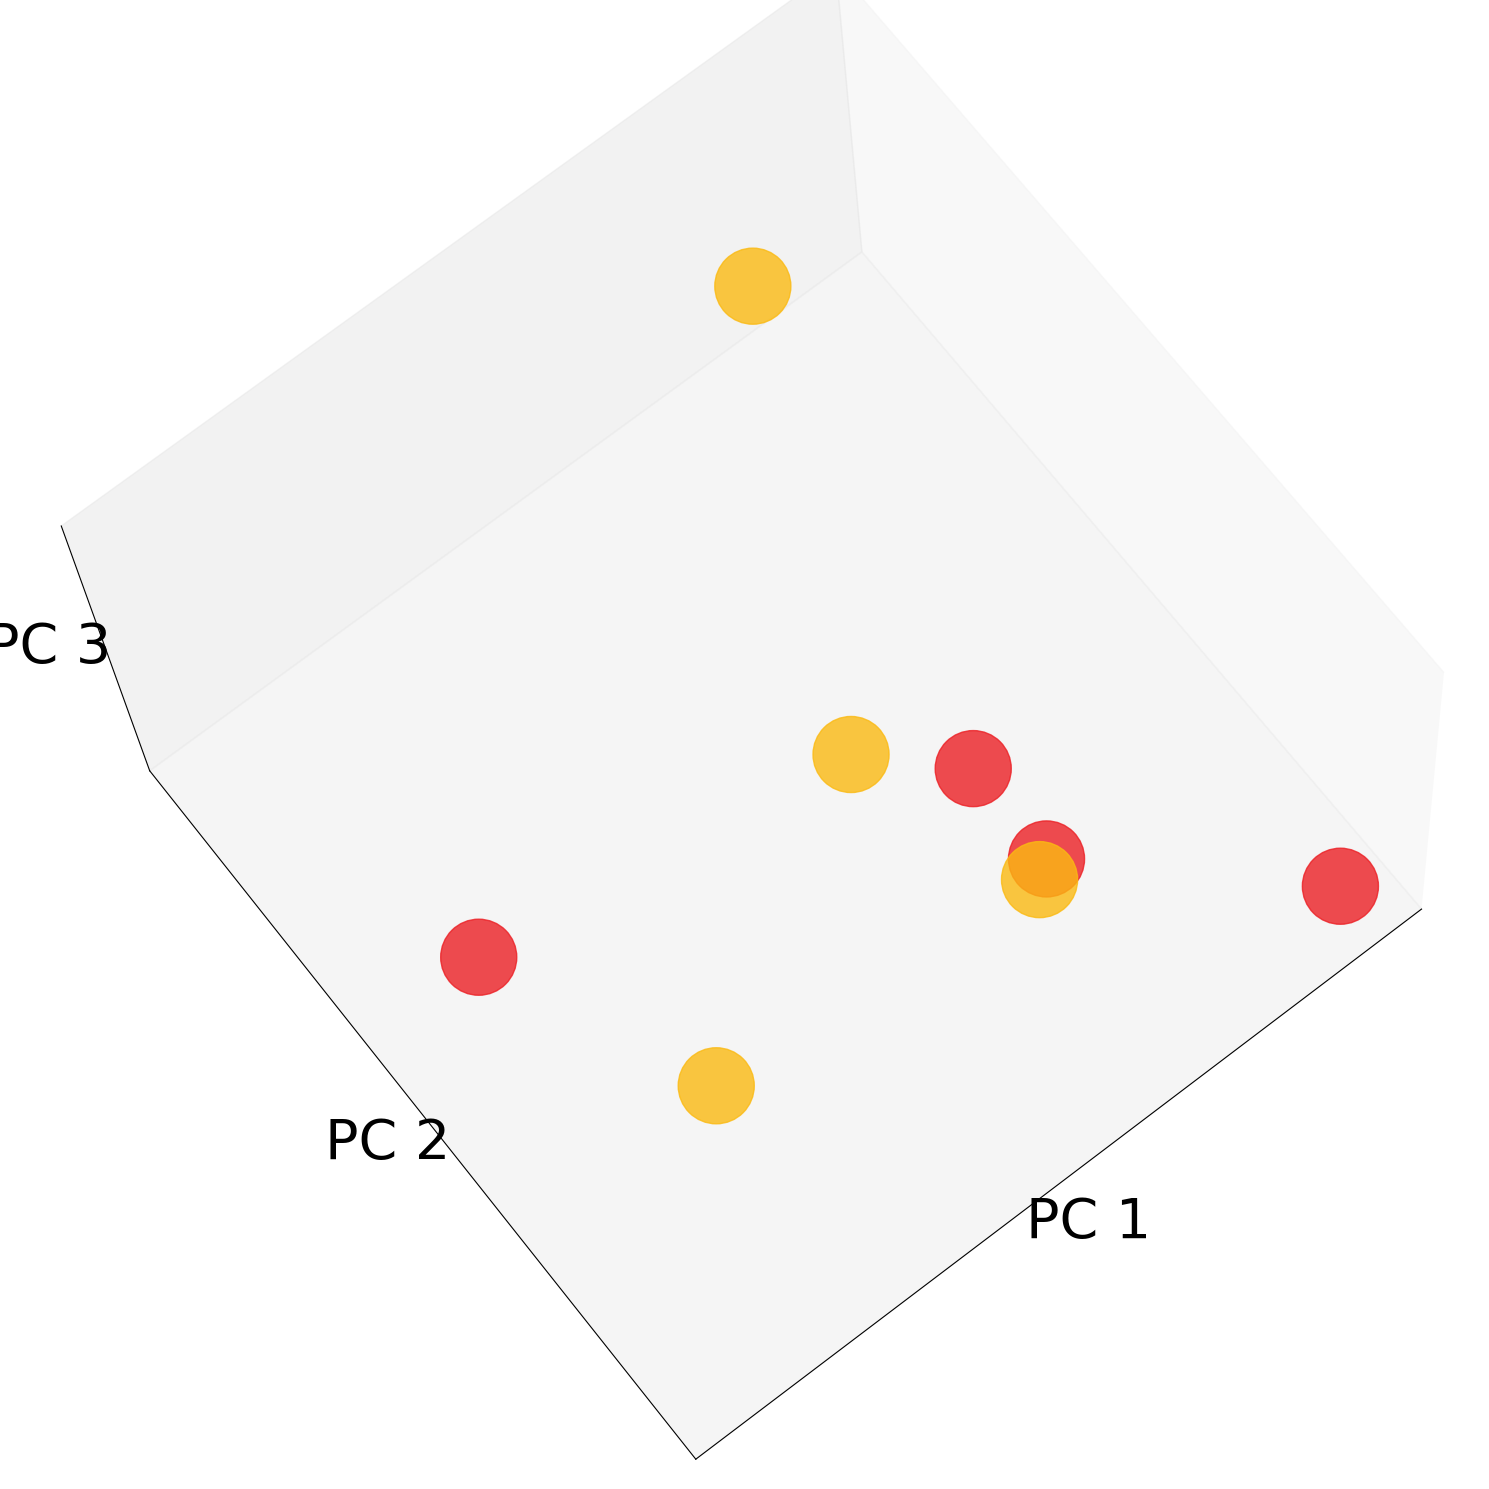

In [8]:
# word based color coding
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_ax, y_ax, z_ax, color=np.array(word_color)[word_label], s=scatter_size, alpha = 0.8)
ax.set_xlabel('PC 1', fontsize = fontsize)
ax.set_ylabel('PC 2', fontsize = fontsize)
ax.set_zlabel('PC 3', fontsize = fontsize)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.view_init(elev = 70, azim = -120, roll = 8) # rev1 (comparison between spb and thx, comparison between -100, 400 ms and -750, 750 ms)    
ax.grid(False)
fig.tight_layout()
# save figure
plt.savefig(f'{savepath_fig}{participant}_{session}_{formatted_datetime}_pca_word_spb_{nbins_before_onset}_{nbins_after_onset}.png', format='png')
